# 02 - Modelo clásico

Entrenamos la SVM-RBF solicitada en el reto.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'main.py').exists())
sys.path.insert(0, str(ROOT))
from prepare_data import load_data
from classical_model import train_classical_svm, evaluate_classical_svm

X_train, X_test, y_train, y_test = load_data(ROOT / 'data/raw/water_potability.csv')
model = train_classical_svm(X_train, y_train)
result, predictions = evaluate_classical_svm(model, X_test, y_test)
result

{'accuracy': 0.6082317073170732,
 'balanced_accuracy': 0.6084375,
 'precision': 0.4984025559105431,
 'recall': 0.609375,
 'f1': 0.5483304042179262,
 'specificity': 0.6075,
 'false_positive_rate': 0.3925,
 'confusion_matrix': [[243, 157], [100, 156]],
 'roc_auc': 0.6464843750000001,
 'average_precision': 0.5261193794641891,
 'best_parameters': {'C': 10, 'gamma': 'auto'},
 'cv_f1_mean': 0.5473789462112324,
 'cv_f1_std': 0.018285786253931447}

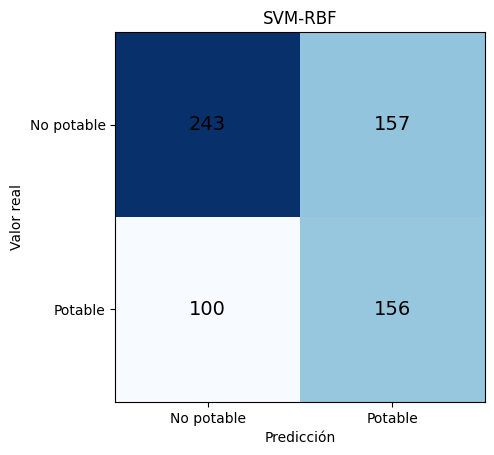

In [2]:
matrix = result['confusion_matrix']
plt.imshow(matrix, cmap='Blues')
for row in range(2):
    for column in range(2):
        plt.text(column, row, matrix[row][column], ha='center', va='center', fontsize=14)
plt.xticks([0, 1], ['No potable', 'Potable'])
plt.yticks([0, 1], ['No potable', 'Potable'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('SVM-RBF')
plt.show()

La imputación, la escala y el balanceo se calculan dentro de cada fold de validación. El test no participa en la búsqueda de `C` y `gamma`.